# U.S. Medical Insurance Costs Analysis

## Project Goal

This project explores demographic and health-related factors associated with individual medical insurance charges in the United States.

The analysis focuses on how insurance charges vary by smoking status, age, BMI, region, sex, and number of children. The findings describe patterns and associations in the dataset; they do not establish causation.

## Analysis Questions

1. What are the average and median insurance charges in the dataset?
2. How do charges differ between smokers and non-smokers?
3. Which region has the highest and lowest average insurance charge?
4. How are age and BMI associated with insurance charges?
5. Do insurance charges differ based on the number of children?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
insurance = pd.read_csv("insurance.csv")

insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Dataset shape:", insurance.shape)
print("\nColumn names:")
print(insurance.columns.tolist())

Dataset shape: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [6]:
print("Data types:")
print(insurance.dtypes)

print("\nMissing values by column:")
print(insurance.isnull().sum())

print("\nDuplicate rows:")
print(insurance.duplicated().sum())

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values by column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows:
1


In [7]:
print("Sex categories:")
print(insurance["sex"].value_counts())

print("\nSmoker categories:")
print(insurance["smoker"].value_counts())

print("\nRegion categories:")
print(insurance["region"].value_counts())

print("\nChildren values:")
print(insurance["children"].value_counts().sort_index())

Sex categories:
sex
male      676
female    662
Name: count, dtype: int64

Smoker categories:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region categories:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Children values:
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [8]:
duplicate_rows = insurance[insurance.duplicated(keep=False)]

duplicate_rows

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
insurance_clean = insurance.drop_duplicates().copy()

print("Original row count:", len(insurance))
print("Cleaned row count:", len(insurance_clean))
print("Remaining duplicate rows:", insurance_clean.duplicated().sum())

Original row count: 1338
Cleaned row count: 1337
Remaining duplicate rows: 0


## Data Quality Summary

The original dataset contains 1,338 records and 7 variables: age, sex, BMI, number of children, smoking status, region, and medical insurance charges.

The data-quality review found no missing values. Categorical variables were consistently formatted, with two sex categories, two smoking-status categories, and four U.S. regions.

One exact duplicate row was identified. I removed this duplicate and created a cleaned dataset containing 1,337 records. All further analysis uses the cleaned dataset.

In [10]:
numeric_summary = insurance_clean[
    ["age", "bmi", "children", "charges"]
].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [11]:
charge_summary = insurance_clean["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max",
    standard_deviation="std"
)

charge_summary

count                  1337.000000
mean                  13279.121487
median                 9386.161300
minimum                1121.873900
maximum               63770.428010
standard_deviation    12110.359656
Name: charges, dtype: float64

In [12]:
print(f"Average insurance charge: ${charge_summary['mean']:,.2f}")
print(f"Median insurance charge: ${charge_summary['median']:,.2f}")
print(f"Minimum insurance charge: ${charge_summary['minimum']:,.2f}")
print(f"Maximum insurance charge: ${charge_summary['maximum']:,.2f}")
print(f"Standard deviation: ${charge_summary['standard_deviation']:,.2f}")

Average insurance charge: $13,279.12
Median insurance charge: $9,386.16
Minimum insurance charge: $1,121.87
Maximum insurance charge: $63,770.43
Standard deviation: $12,110.36


## Descriptive Statistics

The cleaned dataset contains 1,337 insurance records.

The average insurance charge is **$13,279.12**, while the median charge is **$9,386.16**. The mean is substantially higher than the median, which suggests that a smaller number of high-cost observations increase the overall average.

Insurance charges range from **$1,121.87** to **$63,770.43**, with a standard deviation of **$12,110.36**. This wide range indicates substantial variation in insurance charges across individuals.

The average patient age is approximately **39.2 years**, average BMI is **30.7**, and the average number of children is approximately **1.1**.

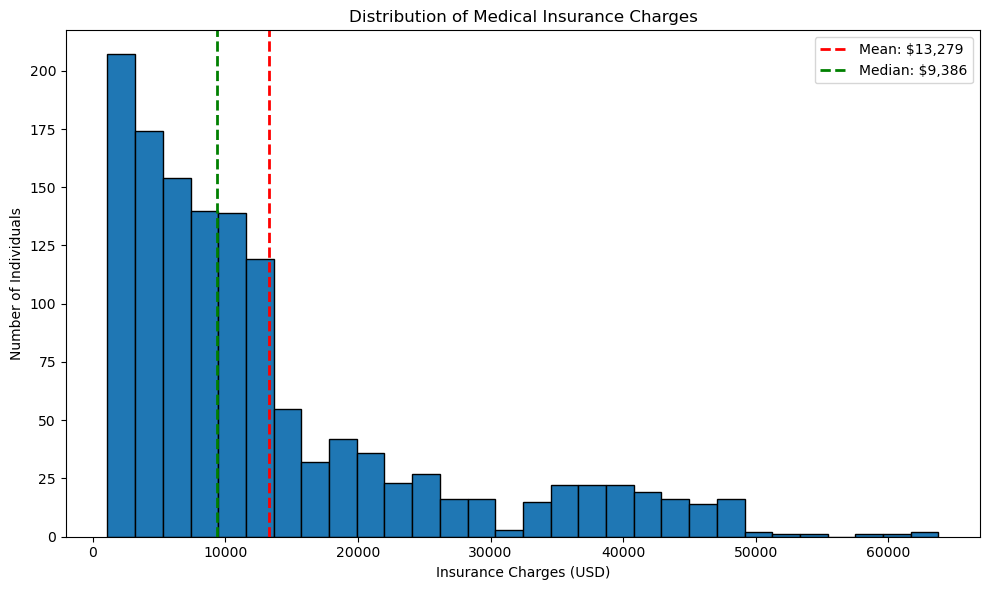

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    insurance_clean["charges"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges (USD)")
plt.ylabel("Number of Individuals")

plt.axvline(
    insurance_clean["charges"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${insurance_clean['charges'].mean():,.0f}"
)

plt.axvline(
    insurance_clean["charges"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: ${insurance_clean['charges'].median():,.0f}"
)

plt.legend()
plt.tight_layout()
plt.show()

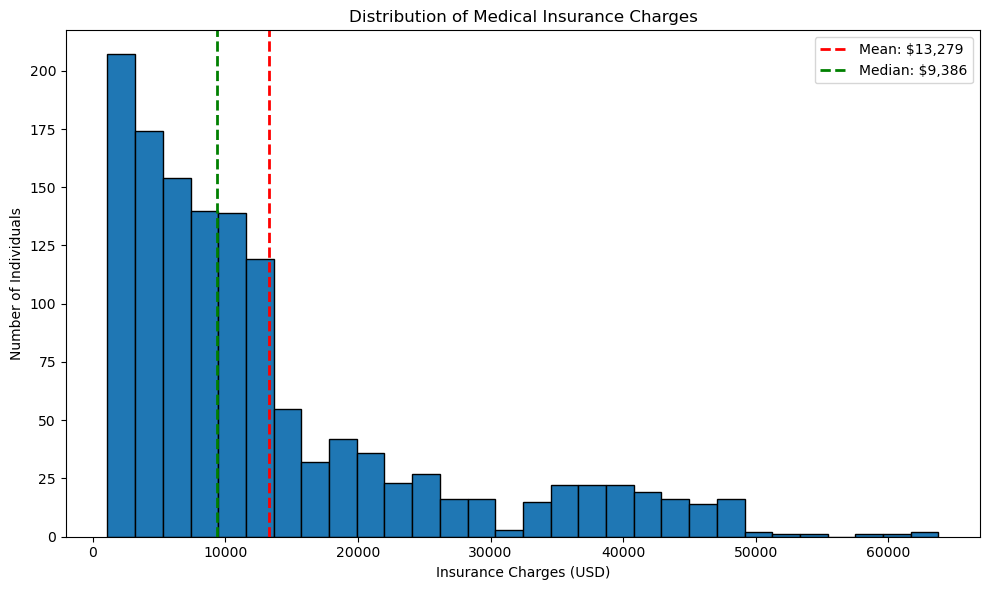

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    insurance_clean["charges"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges (USD)")
plt.ylabel("Number of Individuals")

plt.axvline(
    insurance_clean["charges"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${insurance_clean['charges'].mean():,.0f}"
)

plt.axvline(
    insurance_clean["charges"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: ${insurance_clean['charges'].median():,.0f}"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "insurance_charges_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribution of Insurance Charges

The distribution of insurance charges is strongly right-skewed. Most individuals have charges below approximately $20,000, while a smaller group has substantially higher charges, extending above $60,000.
The mean charge ($13,279) is higher than the median charge ($9,386), which supports the presence of high-cost observations that pull the average upward. Because the distribution is skewed, both mean and median values are used in later comparisons.

In [15]:
smoker_summary = insurance_clean.groupby("smoker")["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
).round(2)

smoker_summary

,count,mean,median,minimum,maximum
smoker,,,,,
no,1063,8440.66,7345.73,1121.87,36910.61
yes,274,32050.23,34456.35,12829.46,63770.43


In [16]:
smoker_mean = smoker_summary.loc["yes", "mean"]
non_smoker_mean = smoker_summary.loc["no", "mean"]

difference = smoker_mean - non_smoker_mean
multiple = smoker_mean / non_smoker_mean

print(f"Average charge for smokers: ${smoker_mean:,.2f}")
print(f"Average charge for non-smokers: ${non_smoker_mean:,.2f}")
print(f"Difference: ${difference:,.2f}")
print(f"Smoker average is {multiple:.1f} times the non-smoker average")

Average charge for smokers: $32,050.23
Average charge for non-smokers: $8,440.66
Difference: $23,609.57
Smoker average is 3.8 times the non-smoker average


## Insurance Charges by Smoking Status

Smoking status has the strongest observed association with medical insurance charges in this dataset.

Non-smokers have an average charge of **$8,440.66**, compared with **$32,050.23** for smokers. This is a difference of **$23,609.57**, meaning the average charge for smokers is approximately **3.8 times** the average charge for non-smokers.

The median charge is also substantially higher for smokers ($34,456.35) than for non-smokers ($7,345.73). This indicates that the difference is not only driven by a few extremely expensive smoker records.

These results show a strong association between smoking status and insurance charges in this dataset. However, this observational analysis does not establish that smoking status alone causes higher insurance charges.

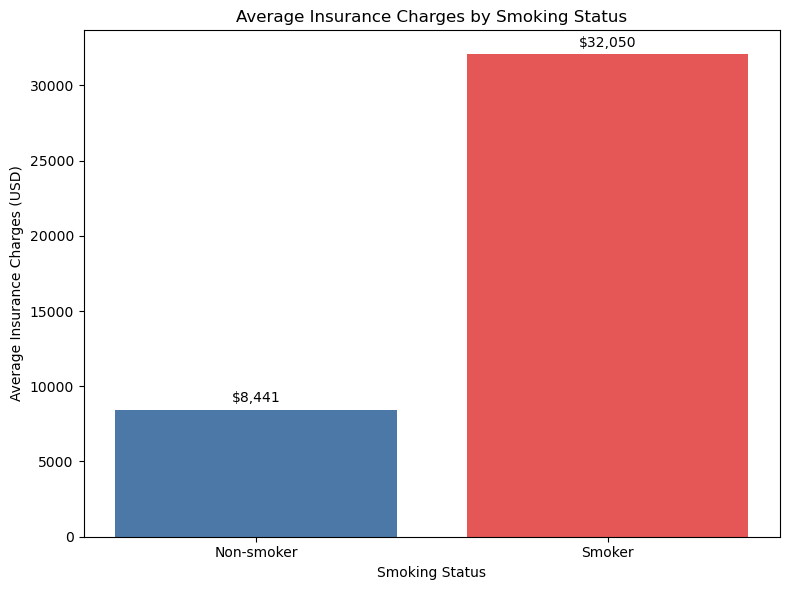

In [17]:
smoker_means = insurance_clean.groupby("smoker")["charges"].mean()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    smoker_means.index,
    smoker_means.values,
    color=["#4C78A8", "#E45756"]
)

plt.title("Average Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges (USD)")

plt.xticks([0, 1], ["Non-smoker", "Smoker"])

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

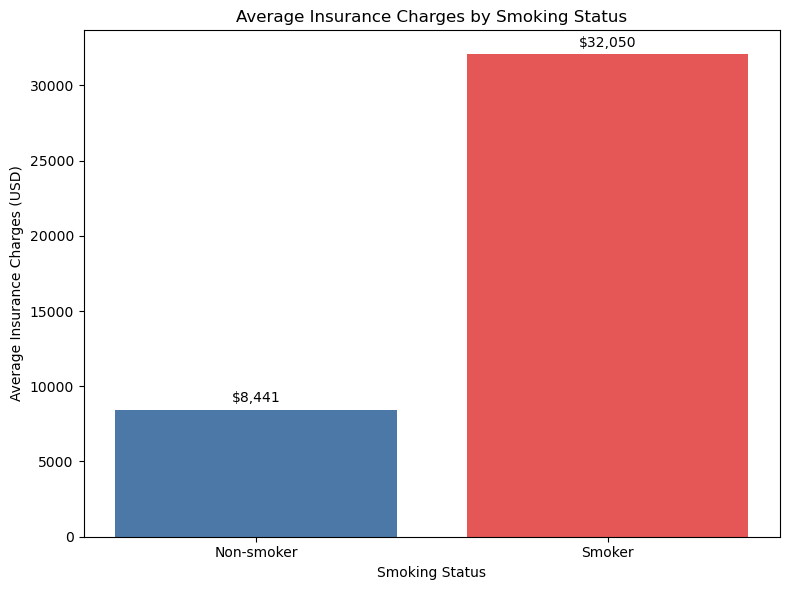

In [18]:
smoker_means = insurance_clean.groupby("smoker")["charges"].mean()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    smoker_means.index,
    smoker_means.values,
    color=["#4C78A8", "#E45756"]
)

plt.title("Average Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges (USD)")

plt.xticks([0, 1], ["Non-smoker", "Smoker"])

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "average_charges_by_smoking_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
region_summary = insurance_clean.groupby("region")["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
).round(2)

region_summary

,count,mean,median,minimum,maximum
region,,,,,
northeast,324,13406.38,10057.65,1694.80,58571.07
northwest,324,12450.84,8976.98,1621.34,60021.40
southeast,364,14735.41,9294.13,1121.87,63770.43
southwest,325,12346.94,8798.59,1241.56,52590.83


In [20]:
region_means = insurance_clean.groupby("region")["charges"].mean().sort_values(
    ascending=False
)

print("Average insurance charge by region:")

for region, average_charge in region_means.items():
    print(f"{region.title()}: ${average_charge:,.2f}")

Average insurance charge by region:
Southeast: $14,735.41
Northeast: $13,406.38
Northwest: $12,450.84
Southwest: $12,346.94


In [21]:
highest_region = region_means.index[0]
lowest_region = region_means.index[-1]

regional_difference = region_means.iloc[0] - region_means.iloc[-1]

print(f"Highest average charge: {highest_region.title()} "
      f"(${region_means.iloc[0]:,.2f})")

print(f"Lowest average charge: {lowest_region.title()} "
      f"(${region_means.iloc[-1]:,.2f})")

print(f"Difference: ${regional_difference:,.2f}")

Highest average charge: Southeast ($14,735.41)
Lowest average charge: Southwest ($12,346.94)
Difference: $2,388.47


## Insurance Charges by Region

Average insurance charges vary across the four U.S. regions, but the regional differences are modest compared with the difference between smokers and non-smokers.

The Southeast has the highest average insurance charge at **$14,735.41**, followed by the Northeast at **$13,406.38**. The Southwest has the lowest average charge at **$12,346.94**.

The difference between the highest and lowest regional averages is **$2,388.47**. This is substantially smaller than the $23,609.57 difference between smoker and non-smoker average charges, suggesting that smoking status is more strongly associated with insurance charges than region in this dataset.

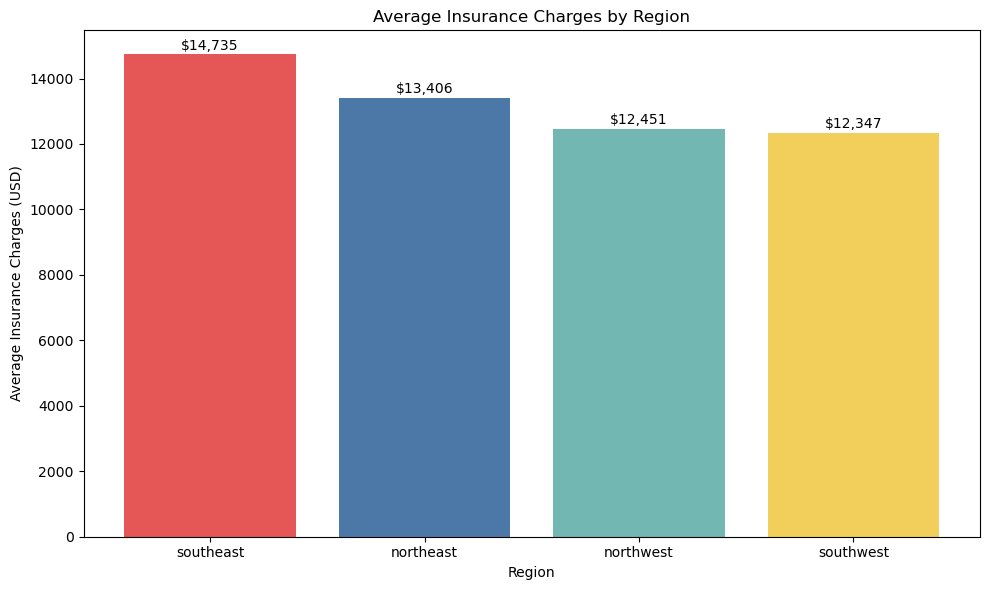

In [22]:
region_means = insurance_clean.groupby("region")["charges"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    region_means.index,
    region_means.values,
    color=["#E45756", "#4C78A8", "#72B7B2", "#F2CF5B"]
)

plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges (USD)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 150,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

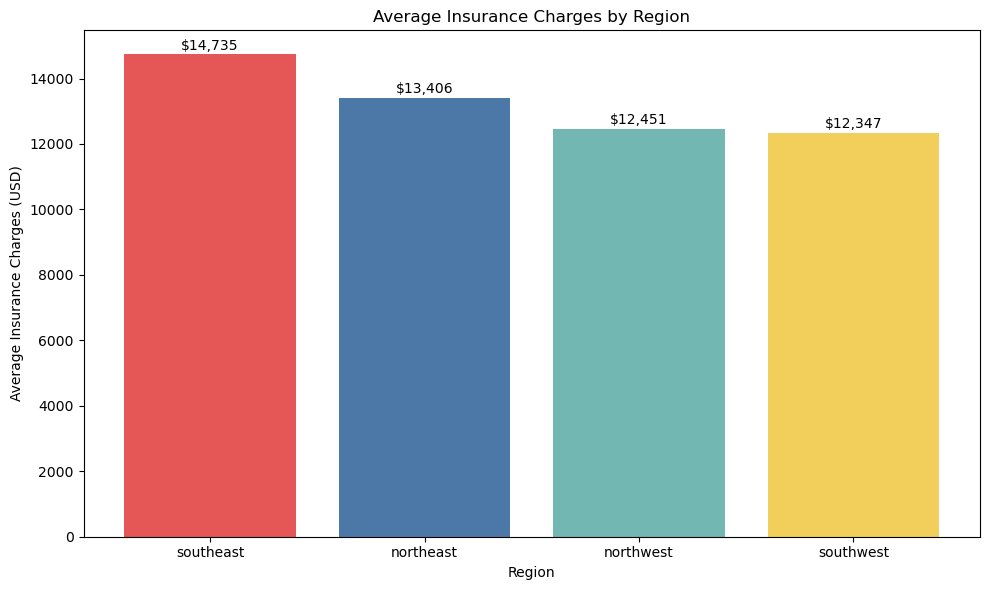

In [23]:
region_means = insurance_clean.groupby("region")["charges"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    region_means.index,
    region_means.values,
    color=["#E45756", "#4C78A8", "#72B7B2", "#F2CF5B"]
)

plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges (USD)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 150,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "average_charges_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
age_charge_correlation = insurance_clean["age"].corr(
    insurance_clean["charges"]
)

bmi_charge_correlation = insurance_clean["bmi"].corr(
    insurance_clean["charges"]
)

print(f"Age and charges correlation: {age_charge_correlation:.3f}")
print(f"BMI and charges correlation: {bmi_charge_correlation:.3f}")

Age and charges correlation: 0.298
BMI and charges correlation: 0.198


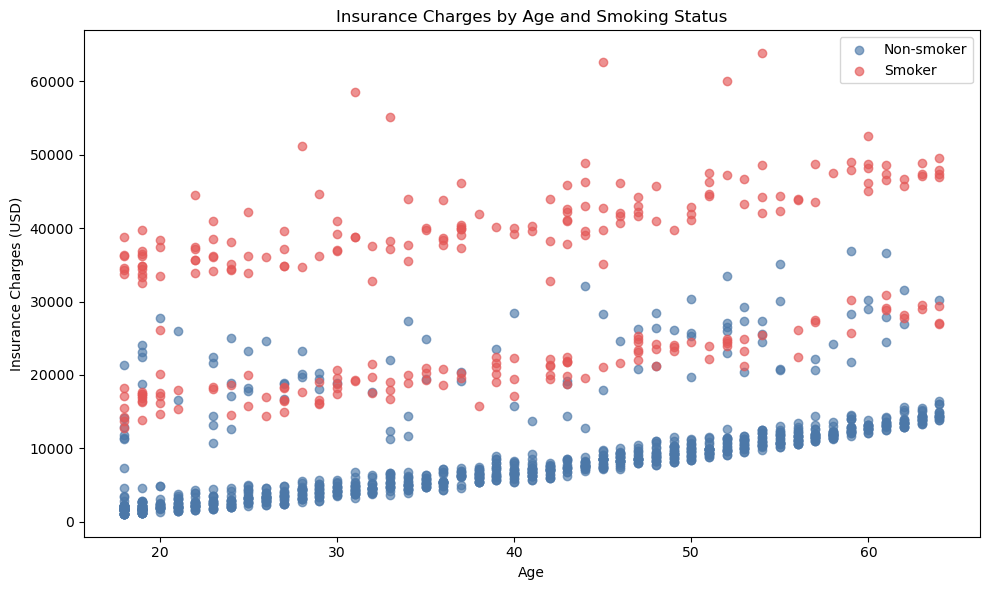

In [25]:
plt.figure(figsize=(10, 6))

for smoker_status, color in [("no", "#4C78A8"), ("yes", "#E45756")]:
    subset = insurance_clean[insurance_clean["smoker"] == smoker_status]

    plt.scatter(
        subset["age"],
        subset["charges"],
        alpha=0.65,
        color=color,
        label="Smoker" if smoker_status == "yes" else "Non-smoker"
    )

plt.title("Insurance Charges by Age and Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges (USD)")
plt.legend()
plt.tight_layout()
plt.show()

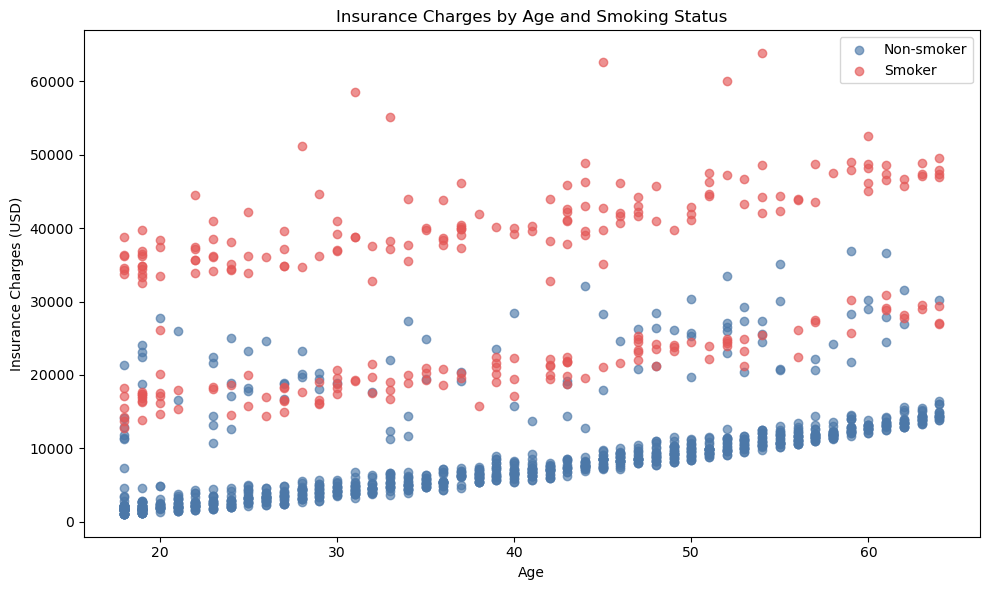

In [26]:
plt.figure(figsize=(10, 6))

for smoker_status, color in [("no", "#4C78A8"), ("yes", "#E45756")]:
    subset = insurance_clean[insurance_clean["smoker"] == smoker_status]

    plt.scatter(
        subset["age"],
        subset["charges"],
        alpha=0.65,
        color=color,
        label="Smoker" if smoker_status == "yes" else "Non-smoker"
    )

plt.title("Insurance Charges by Age and Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges (USD)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "insurance_charges_by_age_and_smoking_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Age, BMI, and Insurance Charges

Age has a moderate positive correlation with insurance charges (**r = 0.298**). This indicates that charges generally tend to increase as age increases, although age alone does not explain all variation in costs.

BMI has a weak positive correlation with insurance charges (**r = 0.198**). This suggests that higher BMI is associated with somewhat higher charges overall, but the relationship is weaker than the relationship observed for age.

The scatter plot shows that smoking status creates clearly different charge patterns. Across most ages, smokers tend to have substantially higher insurance charges than non-smokers. This supports the earlier group comparison, which identified smoking status as the strongest observed factor associated with higher charges in this dataset.

Correlation measures linear association only and does not establish causation.

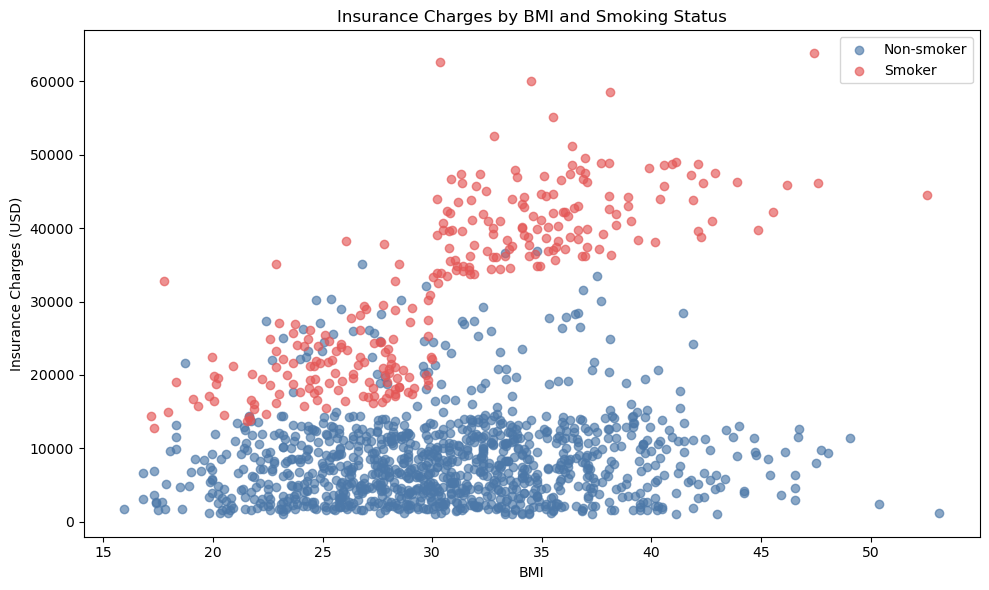

In [27]:
plt.figure(figsize=(10, 6))

for smoker_status, color in [("no", "#4C78A8"), ("yes", "#E45756")]:
    subset = insurance_clean[insurance_clean["smoker"] == smoker_status]

    plt.scatter(
        subset["bmi"],
        subset["charges"],
        alpha=0.65,
        color=color,
        label="Smoker" if smoker_status == "yes" else "Non-smoker"
    )

plt.title("Insurance Charges by BMI and Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges (USD)")
plt.legend()
plt.tight_layout()
plt.show()

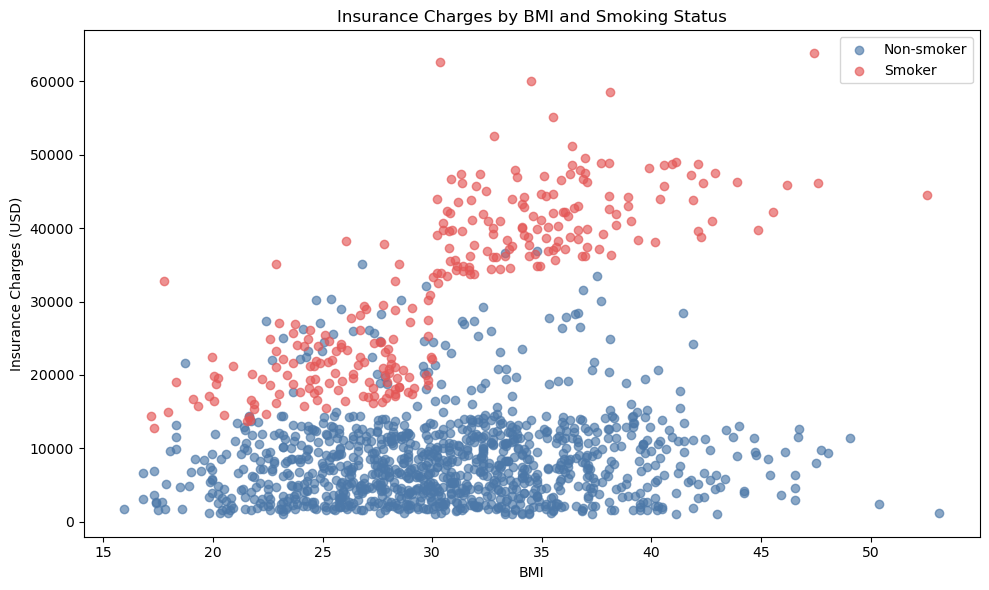

In [28]:
plt.figure(figsize=(10, 6))

for smoker_status, color in [("no", "#4C78A8"), ("yes", "#E45756")]:
    subset = insurance_clean[insurance_clean["smoker"] == smoker_status]

    plt.scatter(
        subset["bmi"],
        subset["charges"],
        alpha=0.65,
        color=color,
        label="Smoker" if smoker_status == "yes" else "Non-smoker"
    )

plt.title("Insurance Charges by BMI and Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges (USD)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "insurance_charges_by_bmi_and_smoking_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
children_summary = insurance_clean.groupby("children")["charges"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
).round(2)

children_summary

,count,mean,median,minimum,maximum
children,,,,,
0,573,12384.70,9863.47,1121.87,63770.43
1,324,12731.17,8483.87,1711.03,58571.07
2,240,15073.56,9264.98,2304.00,49577.66
3,157,15355.32,10600.55,3443.06,60021.40
4,25,13850.66,11033.66,4504.66,40182.25
5,18,8786.04,8589.57,4687.80,19023.26


In [30]:
children_means = insurance_clean.groupby("children")["charges"].mean().sort_index()

print("Average insurance charge by number of children:")

for number_of_children, average_charge in children_means.items():
    print(f"{number_of_children} children: ${average_charge:,.2f}")

Average insurance charge by number of children:
0 children: $12,384.70
1 children: $12,731.17
2 children: $15,073.56
3 children: $15,355.32
4 children: $13,850.66
5 children: $8,786.04


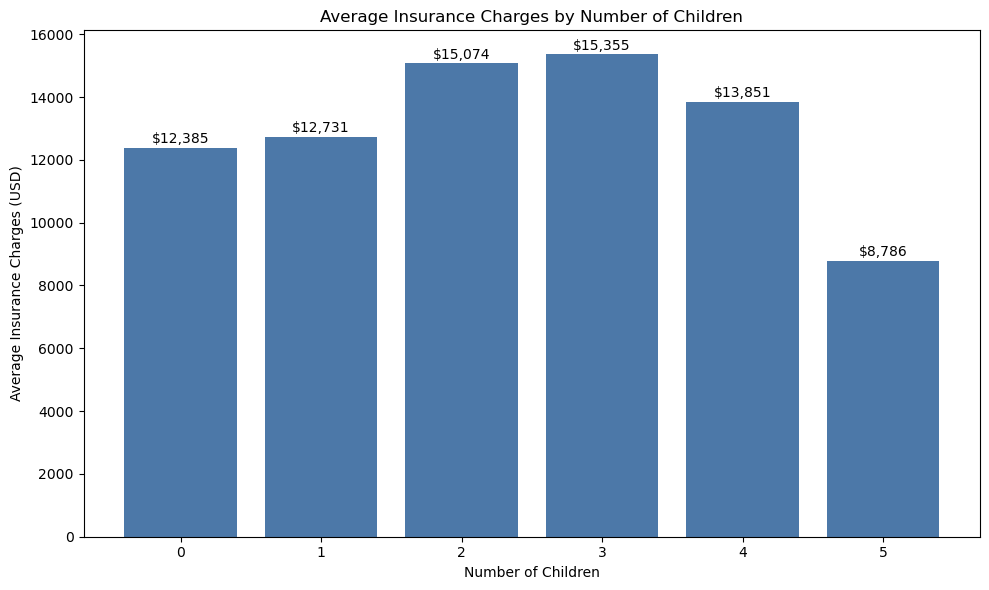

In [31]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    children_means.index.astype(str),
    children_means.values,
    color="#4C78A8"
)

plt.title("Average Insurance Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Insurance Charges (USD)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 150,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Insurance Charges by Number of Children

Average insurance charges do not show a consistent linear relationship with the number of children.

Average charges increase from $12,385 for individuals with no children to $15,355 for individuals with three children. However, average charges decrease for individuals with four and five children, with the five-children category averaging $8,786.

The pattern should be interpreted cautiously because the groups with four and five children contain fewer observations than the groups with zero to three children. Overall, the number of children appears to have a weaker and less consistent association with insurance charges than smoking status, age, or BMI.

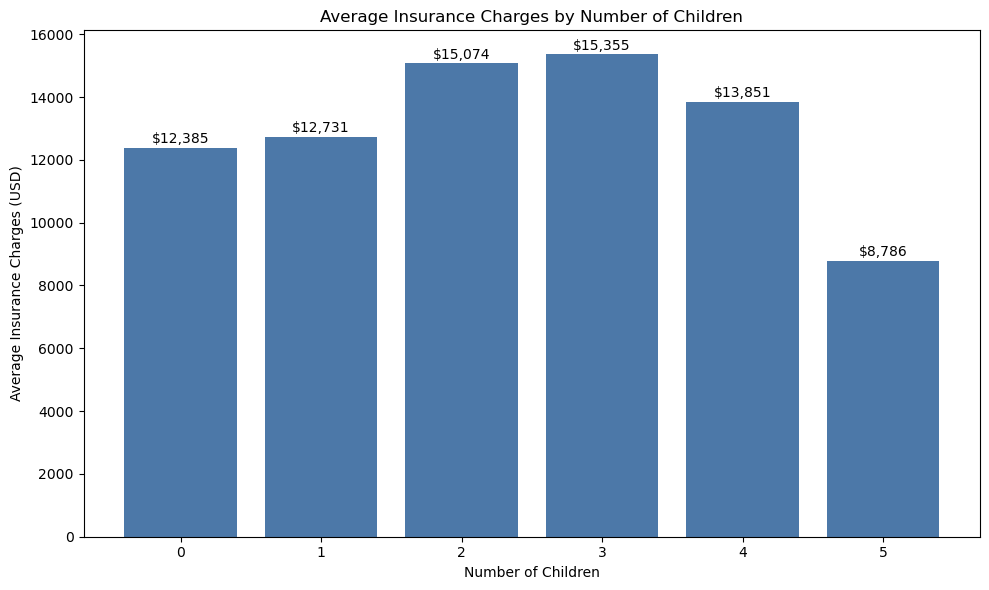

In [32]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    children_means.index.astype(str),
    children_means.values,
    color="#4C78A8"
)

plt.title("Average Insurance Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Insurance Charges (USD)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 150,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "average_charges_by_number_of_children.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final Conclusions

This project analyzed 1,337 cleaned U.S. medical insurance records to identify patterns associated with individual insurance charges.

## Key Findings

1. **Insurance charges are strongly right-skewed.**  
   The average charge was $13,279.12, while the median was $9,386.16. A smaller number of high-cost observations, with charges up to $63,770.43, increased the overall average.

2. **Smoking status had the strongest observed association with insurance charges.**  
   Smokers had an average charge of $32,050.23, compared with $8,440.66 for non-smokers. The average charge for smokers was approximately 3.8 times higher, a difference of $23,609.57.

3. **Region had a smaller association with insurance charges.**  
   The Southeast had the highest average charge at $14,735.41, while the Southwest had the lowest at $12,346.94. The difference between them was $2,388.47.

4. **Age had a moderate positive relationship with charges.**  
   The correlation between age and charges was 0.298, indicating that charges generally tended to increase with age, although age alone did not explain all variation.

5. **BMI had a weak positive relationship with charges.**  
   The correlation between BMI and charges was 0.198. BMI showed a weaker overall relationship with charges than smoking status and age.

6. **The number of children did not show a consistent linear pattern.**  
   Average charges varied across children categories, but the relationship was not consistent and categories with four or five children had relatively fewer observations.

## Limitations and Next Steps

This analysis is exploratory and based on observational data. The results show associations within this dataset and should not be interpreted as proof of causation.

Future work could include:

- Building a regression model to estimate insurance charges.
- Testing whether age, BMI, and smoking status interact with one another.
- Investigating outliers and high-cost records in more detail.
- Using a larger or more representative dataset before making broader conclusions.